# 02 — Model Training (NVIDIA B200)

Step B of the work plan. The notebook trains, tunes, calibrates and evaluates the fraud
model, then exports CPU-loadable artifacts. All logic lives in `src/` (`src/ml/train.py`,
`preprocess.py`, `evaluate.py`, `explain.py`); this notebook only orchestrates and plots.

**How to run on the B200 server:**

1. Upload `b200_bundle.zip` and this notebook to the same folder.
2. Edit nothing except the configuration cell, then *Run All*.
3. Download `b200_outputs_<timestamp>.zip`, written next to the notebook at the end.

Every finished model is checkpointed to `outputs/checkpoints/`. If the kernel dies, *Run All*
again: with `RESUME = True`, finished models and Optuna trials are reloaded, not retrained.

**Data rules:**

- Models are selected on `real_validation.csv`; synthetic rows are only ever used for training.
- `real_test.csv` is opened once, in section 8, and only when `FAST_MODE = False`.
- In FAST_MODE, section 8 runs on real validation as a stand-in, so the CPU smoke test never
  touches the test set.

In [1]:
# ============================ CONFIGURATION (the only cell to edit) ============================
FAST_MODE = True         # True: 20k-row sample, few trials/epochs, CPU OK (laptop smoke test)
RUN_SECTIONS = {
    "baselines": True, "data_mix": True, "zoo": True, "tuning": True, "final_model": True,
    "final_evaluation": True, "explain": True, "save": True,
}
MODELS = ["rf", "xgboost", "lightgbm", "catboost", "mlp"]   # model zoo (LogReg is a baseline)
N_TRIALS = 80            # Optuna trials per finalist (FAST_MODE uses 3)
TUNE_TOP = 2             # tune the best N families from the zoo
SEEDS = [42, 43, 44]     # seed ensemble for the final model and stability checks
RESUME = True            # reuse checkpoints / Optuna trials from an earlier (interrupted) run
INSTALL_REQUIREMENTS = True   # pip install requirements-train.txt (never touches torch/CUDA)

In [2]:
# --- Project root: unpack b200_bundle.zip if it sits next to this notebook -------------------
import os, sys, zipfile, subprocess, json, time, shutil
from pathlib import Path

NB_DIR = Path.cwd()
bundle = NB_DIR / "b200_bundle.zip"
if bundle.exists():
    target = NB_DIR / "b200_bundle"
    stamp = target / ".bundle_mtime"
    if not stamp.exists() or stamp.read_text() != str(bundle.stat().st_mtime):
        if target.exists():
            shutil.rmtree(target)
        zipfile.ZipFile(bundle).extractall(target)
        stamp.write_text(str(bundle.stat().st_mtime))
        print("unpacked", bundle.name)

def find_project_root() -> Path:
    for c in [NB_DIR / "b200_bundle", NB_DIR, *NB_DIR.parents]:
        if (c / "config" / "settings.yaml").exists() and (c / "src").is_dir():
            return c.resolve()
    raise FileNotFoundError("Project not found: put b200_bundle.zip next to this notebook "
                            "or open the notebook inside the repository.")

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))
OUT = NB_DIR / "outputs"
OUT.mkdir(exist_ok=True)
print("PROJECT_ROOT =", PROJECT_ROOT)
print("OUTPUTS      =", OUT)
if (PROJECT_ROOT / "MANIFEST.json").exists():
    man = json.loads((PROJECT_ROOT / "MANIFEST.json").read_text())
    print("bundle commit", man["git_commit"][:10], "created", man["created_utc"])

PROJECT_ROOT = /home/user/AgenticAIFraudInsuranceDetection
OUTPUTS      = /home/user/AgenticAIFraudInsuranceDetection/notebooks/outputs


In [3]:
# --- Install pinned training libraries without touching the preinstalled torch/CUDA stack ----
req = PROJECT_ROOT / "requirements-train.txt"
if INSTALL_REQUIREMENTS and req.exists():
    frozen = subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True).stdout
    keep = [l for l in frozen.splitlines()
            if l.lower().split("==")[0].split(" @ ")[0].startswith(("torch", "nvidia-", "triton", "numpy", "cuda-"))
            and "==" in l]
    constraints = OUT / "constraints-preinstalled.txt"
    constraints.write_text("\n".join(keep) + "\n")
    print("pinning preinstalled packages:", ", ".join(k.split("==")[0] for k in keep) or "(none)")
    r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(req), "-c", str(constraints)],
                       capture_output=True, text=True)
    print(r.stdout[-2000:], r.stderr[-3000:])
    if r.returncode != 0:
        raise RuntimeError("pip install failed (see above). If a pinned version is unavailable for "
                           "this Python, tell Claude the error; do not upgrade torch.")
    import importlib; importlib.invalidate_caches()

pinning preinstalled packages: cuda-bindings, cuda-pathfinder, cuda-toolkit, numpy, nvidia-cublas, nvidia-cuda-cupti, nvidia-cuda-nvrtc, nvidia-cuda-runtime, nvidia-cudnn-cu13, nvidia-cufft, nvidia-cufile, nvidia-curand, nvidia-cusolver, nvidia-cusparse, nvidia-cusparselt-cu13, nvidia-nccl-cu12, nvidia-nccl-cu13, nvidia-nvjitlink, nvidia-nvshmem-cu13, nvidia-nvtx, torch, triton


In [4]:
# --- Environment report (fails early if the GPU cannot be used) -----------------------------
from src.ml.train import environment_report, check_blackwell, detect_device
print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout
      if shutil.which("nvidia-smi") else "nvidia-smi not found (no NVIDIA driver on this machine)")
ENV = environment_report()
for k, v in ENV.items():
    print(f"{k:>20}: {v}")
check_blackwell(ENV, require_gpu=not FAST_MODE)
DEVICE = detect_device()
print("DEVICE =", DEVICE, "| FAST_MODE =", FAST_MODE)

nvidia-smi not found (no NVIDIA driver on this machine)


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


              python: 3.11.15
             sklearn: 1.9.1
               numpy: 2.4.6
              pandas: 3.0.6
             xgboost: 3.2.0
            lightgbm: 4.7.0
            catboost: 1.2.10
                shap: 0.51.0
              optuna: 5.0.0
               torch: 2.14.1+cu130
              joblib: 1.6.0
      cuda_available: False
DEVICE = cpu | FAST_MODE = True


In [5]:
import numpy as np, pandas as pd, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
from src.ml.train import TrainingRun
from src.ml import eda   # shared chart style and palette

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
LOG = OUT / "run_log.txt"
def log(msg):
    line = f"[{time.strftime('%H:%M:%S')}] {msg}"
    print(line, flush=True)
    with open(LOG, "a") as fh:
        fh.write(line + "\n")

run = TrainingRun(OUT, fast=FAST_MODE, device=DEVICE, seeds=SEEDS,
                  n_trials=3 if FAST_MODE else N_TRIALS, tune_top=TUNE_TOP, resume=RESUME, log=log)
FIG = OUT / "figures"
log(f"data: augmented train {len(run.aug):,} rows, real validation {len(run.val):,} rows "
    f"({run.y_val.sum()} frauds); max_rows={run.max_rows}")

[12:14:03] data: augmented train 300,000 rows, real validation 2,313 rows (139 frauds); max_rows=20000


## 1. Baselines: all-legit, rules-only (red flags), class-weighted logistic regression

In [6]:
if RUN_SECTIONS["baselines"]:
    display(run.baselines().round(4))

[12:14:03] baseline: all-legit              val PR-AUC 0.0601 [0.060, 0.060]  ROC-AUC 0.5000  (0s)


[12:14:03] baseline: rules-only (red flags) val PR-AUC 0.1424 [0.124, 0.174]  ROC-AUC 0.7810  (0s)


[12:14:06] logreg                           val PR-AUC 0.1775 [0.146, 0.229]  ROC-AUC 0.7952  (1s)


,model,family,data,pr_auc,pr_lo,pr_hi,roc_auc,precision_at_top_10pct,recall_at_precision_0.3,fit_seconds
2,logreg,logreg,real + 100% synthetic (w=0.3),0.1775,0.1458,0.2287,0.7952,0.1688,0.0432,1.4102
1,baseline: rules-only (red flags),rules,config/policy_rules.yaml,0.1424,0.1239,0.1737,0.7810,0.1645,0.0000,0.0000
0,baseline: all-legit,constant,-,0.0601,0.0601,0.0601,0.5000,0.0649,0.0000,0.0000


## 2. Data-mix experiment (the core research result)

The same XGBoost model is trained on real data only, on real data plus 10–100% of the
synthetic rows, on real data plus all synthetic rows at sample weights 0.1, 0.3 and 1.0, and
on synthetic data only. Each mix is scored by real-validation PR-AUC (mean of 2 seeds). The
best mix is used from here on.

[12:14:07] mix_xgboost_f0.0_w1.0_real_s42   val PR-AUC 0.2311 [0.195, 0.298]  ROC-AUC 0.8307  (1s)


[12:14:09] mix_xgboost_f0.25_w1.0_real_s42  val PR-AUC 0.2198 [0.188, 0.287]  ROC-AUC 0.8384  (1s)


[12:14:12] mix_xgboost_f1.0_w1.0_real_s42   val PR-AUC 0.2387 [0.198, 0.312]  ROC-AUC 0.8380  (2s)


[12:14:14] mix_xgboost_f1.0_w0.3_real_s42   val PR-AUC 0.2321 [0.196, 0.302]  ROC-AUC 0.8415  (2s)


[12:14:17] mix_xgboost_f1.0_w1.0_synonly_s42 val PR-AUC 0.2347 [0.190, 0.312]  ROC-AUC 0.8284  (2s)


[12:14:17] chosen data mix: {'synthetic_fraction': 1.0, 'synthetic_weight': 1.0}


,synthetic_fraction,synthetic_weight,include_real,train_rows,synthetic_rows,pr_auc_mean,pr_auc_sd,pr_auc_seed_avg_scores
0,0.00,1.0,True,10793,0,0.2311,0.0,0.2311
1,0.25,1.0,True,20000,17403,0.2198,0.0,0.2198
2,1.00,1.0,True,19999,19280,0.2387,0.0,0.2387
3,1.00,0.3,True,19999,19280,0.2321,0.0,0.2321
4,1.00,1.0,False,20000,20000,0.2347,0.0,0.2347


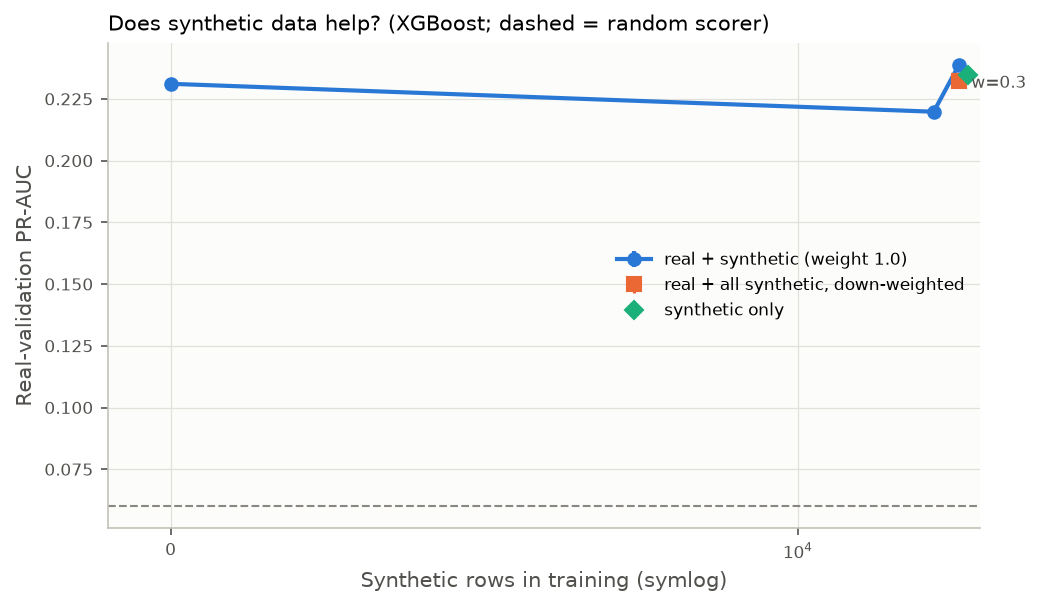

In [7]:
if RUN_SECTIONS["data_mix"]:
    mix = run.data_mix("xgboost")
    display(mix.round(4))
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    m1 = mix[(mix.synthetic_weight == 1.0) & mix.include_real].sort_values("synthetic_rows")
    ax.errorbar(m1.synthetic_rows, m1.pr_auc_mean, yerr=m1.pr_auc_sd, fmt="o-", lw=2, ms=6, capsize=0,
                color=eda.ORIGIN_COLORS["real_train"], label="real + synthetic (weight 1.0)")
    mw = mix[(mix.synthetic_weight != 1.0) & mix.include_real]
    ax.errorbar(mw.synthetic_rows, mw.pr_auc_mean, yerr=mw.pr_auc_sd, fmt="s", ms=7, capsize=0,
                color=eda.ORIGIN_COLORS["synthetic"], label="real + all synthetic, down-weighted")
    for _, r in mw.iterrows():
        ax.annotate(f"w={r.synthetic_weight}", (r.synthetic_rows, r.pr_auc_mean), xytext=(6, -3),
                    textcoords="offset points", fontsize=8, color=eda.INK_2)
    so = mix[~mix.include_real]
    ax.errorbar(so.synthetic_rows, so.pr_auc_mean, yerr=so.pr_auc_sd, fmt="D", ms=6, capsize=0,
                color=eda.ORIGIN_COLORS["real_validation"], label="synthetic only")
    ax.axhline(run.y_val.mean(), color=eda.MUTED, ls="--", lw=1)
    ax.set_xscale("symlog", linthresh=10_000); ax.set_xlabel("Synthetic rows in training (symlog)")
    ax.set_ylabel("Real-validation PR-AUC"); ax.legend(frameon=False, fontsize=8)
    ax.set_title("Does synthetic data help? (XGBoost; dashed = random scorer)", loc="left", fontsize=10)
    ax.grid(color=eda.GRID, lw=0.6); eda.style_axes(ax)
    eda.save(fig, FIG / "data_mix.png"); display(Image(FIG / "data_mix.png"))

## 3. Model zoo (class-weighted; GPU for XGBoost, CatBoost and the MLP)

[12:14:19] rf                               val PR-AUC 0.2172 [0.178, 0.283]  ROC-AUC 0.8264  (2s)


[12:14:22] xgboost                          val PR-AUC 0.2387 [0.198, 0.312]  ROC-AUC 0.8380  (2s)


[12:14:25] lightgbm                         val PR-AUC 0.2276 [0.187, 0.296]  ROC-AUC 0.8336  (2s)


[12:14:34] catboost                         val PR-AUC 0.2253 [0.187, 0.298]  ROC-AUC 0.8347  (8s)


[12:14:38] mlp                              val PR-AUC 0.2037 [0.161, 0.261]  ROC-AUC 0.8069  (4s)


,model,family,data,pr_auc,pr_lo,pr_hi,roc_auc,precision_at_top_10pct,recall_at_precision_0.3,fit_seconds
5,mix_xgboost_f1.0_w1.0_real_s42,xgboost,real + 100% synthetic (w=1.0),0.2387,0.1984,0.3116,0.8380,0.2294,0.1151,1.6862
9,xgboost,xgboost,real + 100% synthetic (w=1.0),0.2387,0.1984,0.3116,0.8380,0.2294,0.1151,2.0803
7,mix_xgboost_f1.0_w1.0_synonly_s42,xgboost,no real + 100% synthetic (w=1.0),0.2347,0.1900,0.3120,0.8284,0.2165,0.1367,1.9011
6,mix_xgboost_f1.0_w0.3_real_s42,xgboost,real + 100% synthetic (w=0.3),0.2321,0.1960,0.3017,0.8415,0.2424,0.1871,1.6107
3,mix_xgboost_f0.0_w1.0_real_s42,xgboost,real + 0% synthetic (w=1.0),0.2311,0.1947,0.2976,0.8307,0.2294,0.1799,1.3276
10,lightgbm,lightgbm,real + 100% synthetic (w=1.0),0.2276,0.1874,0.2962,0.8336,0.2251,0.1367,1.9505
11,catboost,catboost,real + 100% synthetic (w=1.0),0.2253,0.1869,0.2978,0.8347,0.2251,0.1295,8.0352
4,mix_xgboost_f0.25_w1.0_real_s42,xgboost,real + 25% synthetic (w=1.0),0.2198,0.1875,0.2869,0.8384,0.2511,0.1079,1.4974
8,rf,rf,real + 100% synthetic (w=1.0),0.2172,0.1780,0.2834,0.8264,0.2078,0.1583,1.5317
12,mlp,mlp,real + 100% synthetic (w=1.0),0.2037,0.1613,0.2606,0.8069,0.1948,0.1295,3.6110


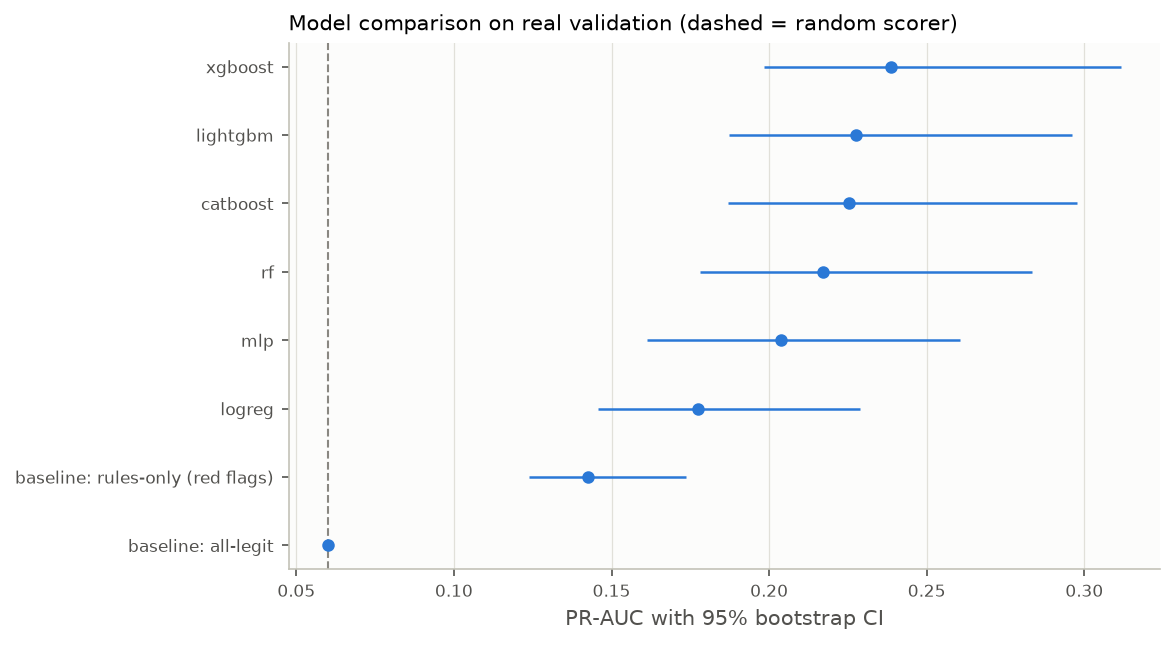

In [8]:
if RUN_SECTIONS["zoo"]:
    zoo = run.zoo(MODELS)
    display(zoo.round(4))
    t = zoo[~zoo.model.str.startswith("mix_")]
    fig, ax = plt.subplots(figsize=(7.5, 0.42 * len(t) + 1.2))
    eda.plot_dots(ax, t.model.tolist(), {"PR-AUC (real validation)": (t.pr_auc, t.pr_lo, t.pr_hi)},
                  "PR-AUC with 95% bootstrap CI", ref=run.y_val.mean())
    ax.set_title("Model comparison on real validation (dashed = random scorer)", loc="left", fontsize=10)
    eda.save(fig, FIG / "model_comparison.png"); display(Image(FIG / "model_comparison.png"))

## 4. Optuna tuning of the best families

TPE sampling maximises real-validation PR-AUC. To avoid picking a lucky trial with only 139
validation frauds, the top 5 trials are each refitted with 3 seeds, and the configuration with
the best **mean** score is kept. Trials are stored in `outputs/optuna.db`, so an interrupted
run resumes where it stopped.

In [9]:
if RUN_SECTIONS["tuning"]:
    display(run.tune_best().round(4))

[12:14:39] tuning xgboost: 3 trials


[12:14:42]   xgboost trial 0: PR-AUC 0.2387 (best 0.2387)


[12:14:43]   xgboost trial 1: PR-AUC 0.2482 (best 0.2482)


[12:14:45]   xgboost trial 2: PR-AUC 0.2390 (best 0.2482)


[12:14:48] tuning lightgbm: 3 trials


[12:14:50]   lightgbm trial 0: PR-AUC 0.2396 (best 0.2396)


[12:14:51]   lightgbm trial 1: PR-AUC 0.2175 (best 0.2396)


[12:14:53]   lightgbm trial 2: PR-AUC 0.2231 (best 0.2396)


,family,default_pr_auc,best_single_trial,chosen_mean_pr_auc_over_seeds,chosen_sd,trials
0,xgboost,0.2387,0.2482,0.2482,0.0,3
1,lightgbm,0.2276,0.2396,0.2396,0.0,3


## 5. Final model: seed ensemble with cross-fitted calibration and cost-based thresholds

[12:14:57] final xgboost seed 42: val PR-AUC 0.2482


[12:14:57] final model: xgboost x1 seeds, calibration=sigmoid, bands={'medium': 0.07207935452461242, 'high': 0.11788880750536919}


calibration: sigmoid | Brier uncalibrated 0.1519, Platt 0.0505, isotonic 0.0514 (out-of-fold)


,cost_ratio,threshold,bayes_threshold,cost_per_claim,flag_rate,precision,recall
cost_10to1,10.0,0.1179,0.0909,0.3476,0.2127,0.1992,0.7050
cost_5to1,5.0,0.1657,0.1667,0.2443,0.1202,0.2446,0.4892
cost_20to1,20.0,0.0721,0.0476,0.4773,0.3377,0.1498,0.8417
capacity_top_10pct,NaN,0.1789,NaN,NaN,0.1003,0.2414,0.4029


risk bands: {'medium': 0.07207935452461242, 'high': 0.11788880750536919}


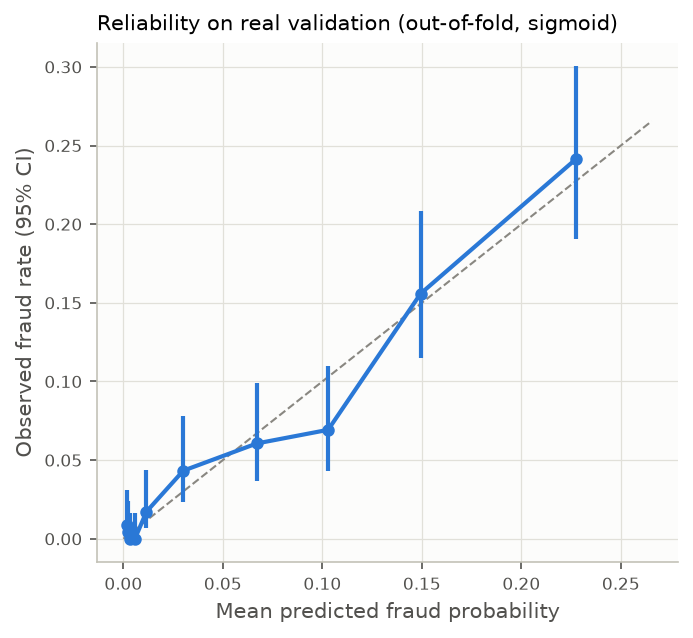

In [10]:
if RUN_SECTIONS["final_model"]:
    final = run.finalize()
    cal = final["calibration"]
    print(f"calibration: {cal['method']} | Brier uncalibrated {cal['uncalibrated_brier']:.4f}, "
          f"Platt {cal['sigmoid']['brier']:.4f}, isotonic {cal['isotonic']['brier']:.4f} (out-of-fold)")
    display(pd.DataFrame(final["thresholds"]).T.round(4))
    print("risk bands:", final["risk_bands"])

    from src.ml.evaluate import reliability_table
    rel = reliability_table(run.y_val, final["oof_cal"])
    fig, ax = plt.subplots(figsize=(5, 4.5))
    lim = max(rel.mean_pred.max(), rel.observed.max()) * 1.1
    ax.plot([0, lim], [0, lim], color=eda.MUTED, ls="--", lw=1)
    ax.errorbar(rel.mean_pred, rel.observed, yerr=np.clip([rel.observed - rel.lo, rel.hi - rel.observed], 0, None),
                fmt="o-", color=eda.ORIGIN_COLORS["real_train"], lw=2, ms=5, capsize=0)
    ax.set_xlabel("Mean predicted fraud probability"); ax.set_ylabel("Observed fraud rate (95% CI)")
    ax.set_title(f"Reliability on real validation (out-of-fold, {cal['method']})", loc="left", fontsize=10)
    ax.grid(color=eda.GRID, lw=0.6); eda.style_axes(ax)
    eda.save(fig, FIG / "reliability.png"); display(Image(FIG / "reliability.png"))

## 6. Decision policy

| Condition | Recommendation |
|---|---|
| score ≥ `high` band (10:1 cost threshold) | **FLAG_FOR_INVESTIGATION** |
| blocking validation failure (e.g. missing age) | **REQUEST_MORE_INFO** |
| otherwise | **APPROVE**, always subject to adjuster review |

The 5:1 and 20:1 thresholds and the top-10% capacity threshold are reported alongside, in
`thresholds.csv` and `model_card.json`.

## 7. Saving checkpoints before the test set is opened

In [11]:
if RUN_SECTIONS["save"] and RUN_SECTIONS["final_model"]:
    run.save_artifacts()     # saved now so a crash in later sections never loses the model

[12:14:57] saved artifacts to /home/user/AgenticAIFraudInsuranceDetection/notebooks/outputs/models: fraud_model.joblib, model_card.json, preprocessor.joblib


## 8. Final held-out evaluation (real test, opened once; validation stand-in in FAST_MODE)

[12:15:04] evaluated on real_validation: n=2313, frauds=139


,metric,value,lo,hi
0,roc_auc,0.8390,0.8162,0.8670
1,pr_auc,0.2482,0.2015,0.3275
2,brier,0.0504,0.0485,0.0519
3,recall_at_precision_0.3,0.1655,0.0644,0.5112
4,precision_at_top_5pct,0.2672,0.2067,0.3448
5,precision_at_top_10pct,0.2554,0.2121,0.2988
6,accuracy,0.8124,0.7946,0.8262
7,precision,0.1984,0.1797,0.2220
8,recall,0.6978,0.6329,0.7770
9,f1,0.3089,0.2796,0.3432


,model,pr_auc,roc_auc,precision,recall,f1,f2,fpr,accuracy,pr_auc_ci
0,final model (calibrated),0.2482,0.8390,0.1984,0.6978,0.3089,0.4641,0.1803,0.8124,"[0.201, 0.328]"
1,rules-only (red flags),0.1424,0.7810,0.1470,0.6259,0.2380,0.3789,0.2323,0.7592,"[0.124, 0.174]"
2,all-legit,0.0601,0.5000,0.0601,1.0000,0.1134,0.2422,1.0000,0.0601,"[0.060, 0.060]"
3,logistic regression,0.1775,0.7952,0.1554,0.5468,0.2420,0.3636,0.1900,0.7942,"[0.146, 0.229]"


Success criterion (precision and recall both meaningfully above naive): MET
  precision lower CI 0.180 vs random-flagging precision 0.060
  recall lower CI 0.633 vs random recall at the same flag rate 0.211


,decile,n,fraud,min_score,rate,lift,cumulative_recall
0,1,232,59,0.178,0.254,4.232,0.424
1,2,231,34,0.123,0.147,2.449,0.669
2,3,231,15,0.085,0.065,1.081,0.777
3,4,232,15,0.049,0.065,1.076,0.885
4,5,231,10,0.016,0.043,0.720,0.957
5,6,231,3,0.008,0.013,0.216,0.978
6,7,232,0,0.004,0.000,0.000,0.978
7,8,231,1,0.003,0.004,0.072,0.986
8,9,231,1,0.002,0.004,0.072,0.993
9,10,231,1,0.002,0.004,0.072,1.000


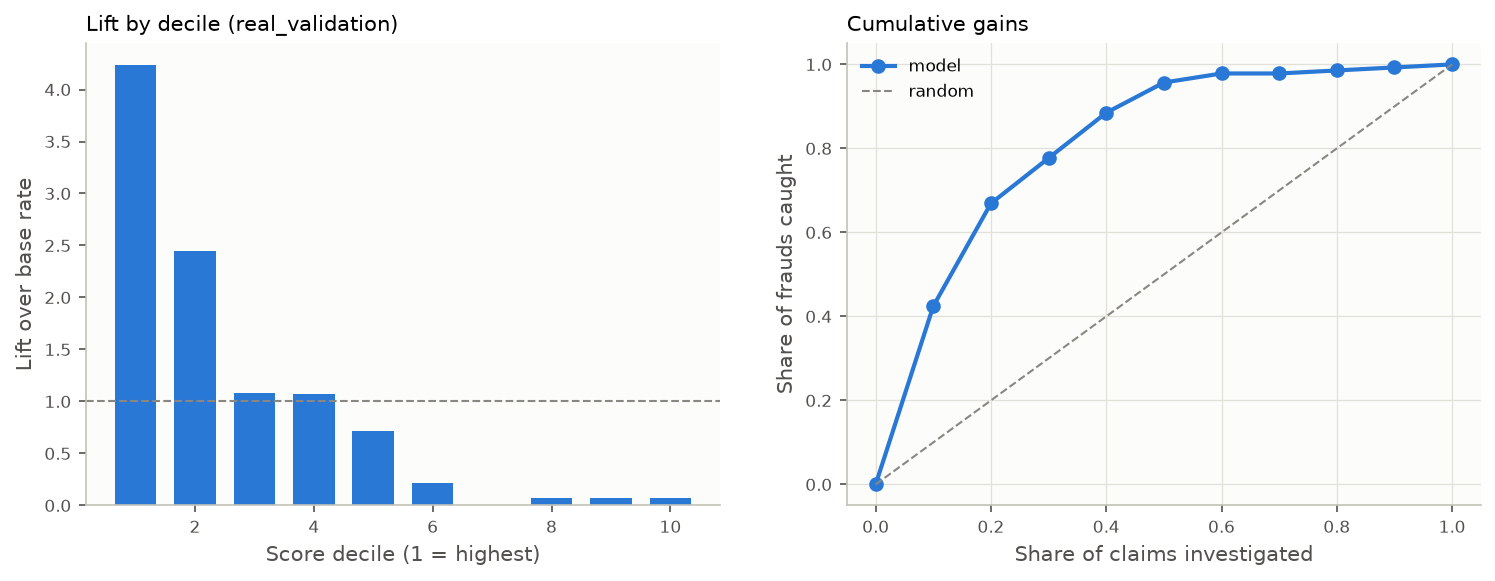

In [12]:
if RUN_SECTIONS["final_evaluation"]:
    SPLIT = "real_validation" if FAST_MODE else "real_test"
    ev = run.evaluate(SPLIT)
    log(f"evaluated on {SPLIT}: n={ev['n']}, frauds={ev['fraud']}")
    display(ev["metrics"].round(4))
    display(ev["comparison"].round(4))
    s = ev["success"]
    print(f"Success criterion (precision and recall both meaningfully above naive): {'MET' if s['met'] else 'NOT MET'}\n"
          f"  precision lower CI {s['precision_lo']:.3f} vs random-flagging precision {s['random_precision']:.3f}\n"
          f"  recall lower CI {s['recall_lo']:.3f} vs random recall at the same flag rate {s['random_recall_at_same_flag_rate']:.3f}")
    display(ev["lift"].round(3))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    lt = ev["lift"]
    axes[0].bar(lt.decile, lt.lift, color=eda.ORIGIN_COLORS["real_train"], width=0.7)
    axes[0].axhline(1, color=eda.MUTED, ls="--", lw=1)
    axes[0].set_xlabel("Score decile (1 = highest)"); axes[0].set_ylabel("Lift over base rate")
    axes[0].set_title(f"Lift by decile ({SPLIT})", loc="left", fontsize=10); eda.style_axes(axes[0])
    axes[1].plot(np.r_[0, lt.decile / 10], np.r_[0, lt.cumulative_recall], "o-", lw=2,
                 color=eda.ORIGIN_COLORS["real_train"], label="model")
    axes[1].plot([0, 1], [0, 1], color=eda.MUTED, ls="--", lw=1, label="random")
    axes[1].set_xlabel("Share of claims investigated"); axes[1].set_ylabel("Share of frauds caught")
    axes[1].legend(frameon=False, fontsize=8); axes[1].set_title("Cumulative gains", loc="left", fontsize=10)
    axes[1].grid(color=eda.GRID, lw=0.6); eda.style_axes(axes[1])
    eda.save(fig, FIG / "lift.png"); display(Image(FIG / "lift.png"))

## 9. Explainability (SHAP), error analysis and fairness

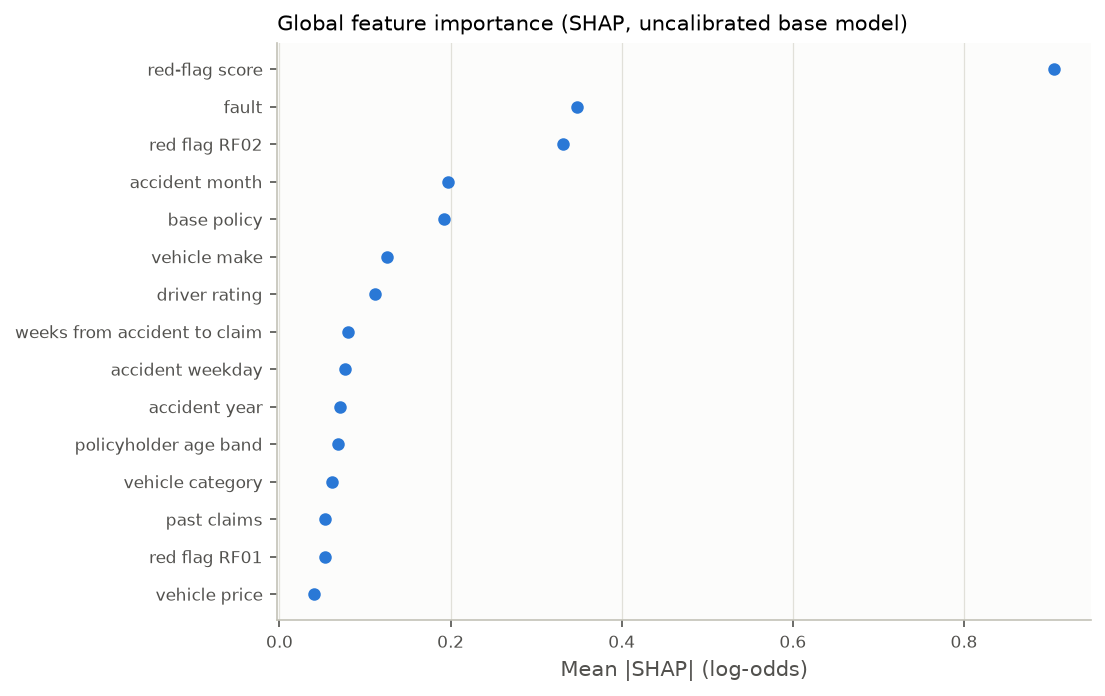

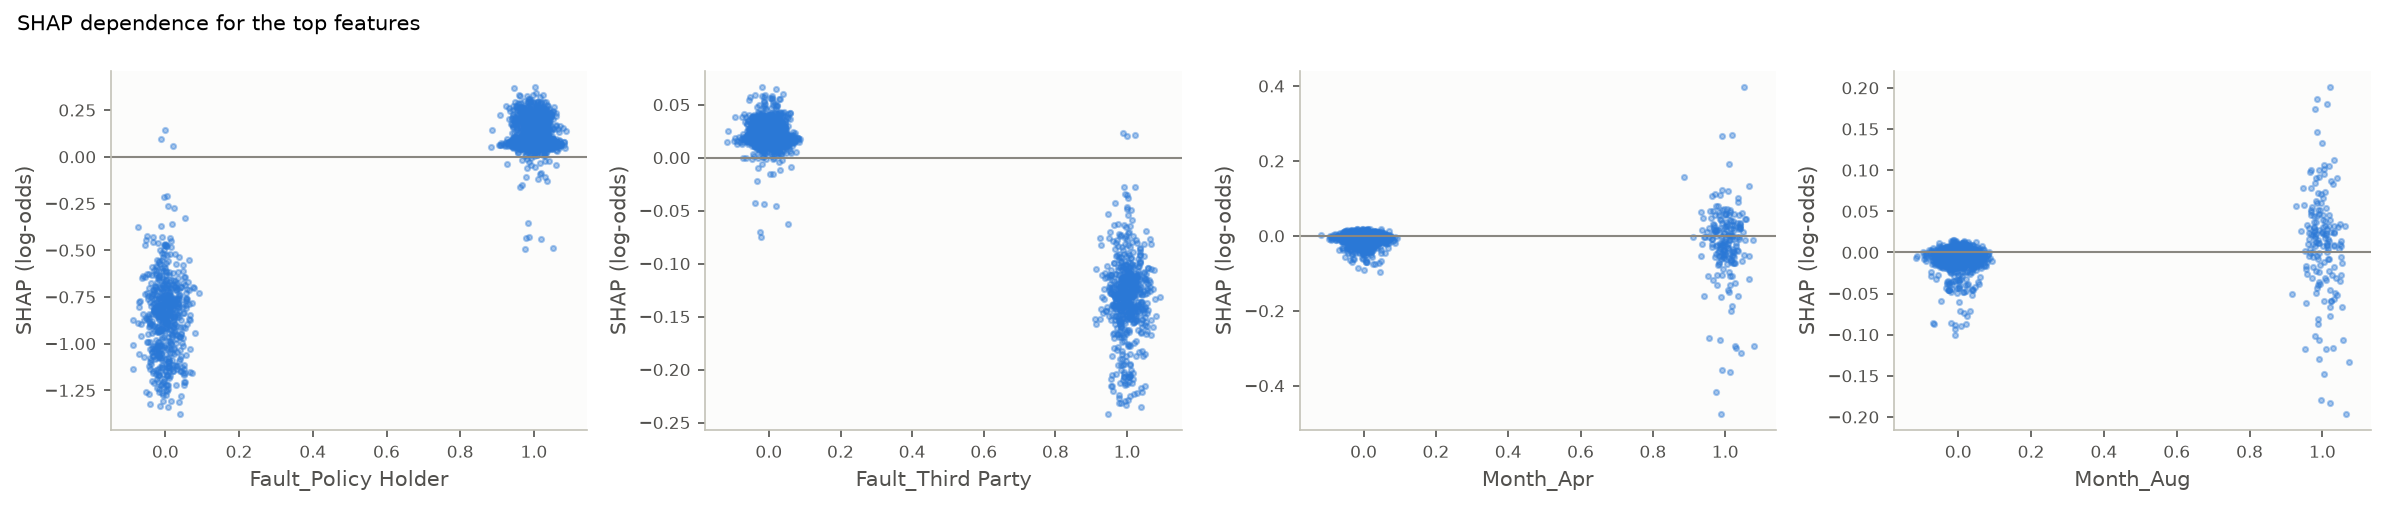

,case,row,score,feature,value,shap_contribution,reason
0,true_positive,165,0.604290,red-flag score,5.0,2.6497,red-flag score = 5.0 raises the fraud score
1,true_positive,165,0.604290,red flag RF02,0.0,-0.3758,red flag RF02 = 0.0 lowers the fraud score
2,true_positive,165,0.604290,red flag RF03,1.0,0.3337,red flag RF03 = 1.0 raises the fraud score
3,true_positive,165,0.604290,red flag RF04,1.0,0.2900,red flag RF04 = 1.0 raises the fraud score
4,true_positive,165,0.604290,policyholder age band,6.0,-0.1821,policyholder age band = 6.0 lowers the fraud s...
5,true_positive,446,0.428173,red-flag score,5.0,2.4144,red-flag score = 5.0 raises the fraud score
6,true_positive,446,0.428173,red flag RF02,0.0,-0.2857,red flag RF02 = 0.0 lowers the fraud score
7,true_positive,446,0.428173,driver rating,4,0.1461,driver rating = 4 raises the fraud score
8,true_positive,446,0.428173,vehicle age,new,-0.1380,vehicle age = new lowers the fraud score
9,true_positive,446,0.428173,weeks from accident to claim,0.0,-0.1295,weeks from accident to claim = 0.0 lowers the ...


In [13]:
if RUN_SECTIONS["explain"] and RUN_SECTIONS["final_evaluation"]:
    sh = run.explain()
    imp = sh["importance"].head(15)
    fig, ax = plt.subplots(figsize=(7, 5))
    eda.plot_dots(ax, imp.index.tolist(), {"mean |SHAP|": (imp.values, None, None)}, "Mean |SHAP| (log-odds)")
    ax.set_title("Global feature importance (SHAP, uncalibrated base model)", loc="left", fontsize=10)
    eda.save(fig, FIG / "shap_global.png"); display(Image(FIG / "shap_global.png"))

    from src.ml.explain import describe_feature
    names = sh["names"]; X = np.asarray(sh["X"], dtype=float) if run.final["family"] != "catboost" else None
    top_feats = [n for n in names if describe_feature(n)[0].split(" = ")[0] in imp.index[:4].tolist()][:4]
    if X is not None and top_feats:
        fig, axes = plt.subplots(1, len(top_feats), figsize=(4 * len(top_feats), 3.4), squeeze=False)
        for ax, fname in zip(axes[0], top_feats):
            j = names.index(fname)
            ax.scatter(X[:, j] + np.random.default_rng(0).normal(0, 0.03, len(X)), sh["values"][:, j], s=6,
                       alpha=0.4, color=eda.ORIGIN_COLORS["real_train"])
            ax.axhline(0, color=eda.MUTED, lw=1); ax.set_xlabel(fname); ax.set_ylabel("SHAP (log-odds)")
            eda.style_axes(ax)
        fig.suptitle("SHAP dependence for the top features", x=0.01, ha="left", fontsize=10)
        fig.tight_layout(); eda.save(fig, FIG / "shap_dependence.png"); display(Image(FIG / "shap_dependence.png"))
    display(sh["local"])

Segments where frauds are missed most (n >= 50, recall lowest):


,segment,group,n,fraud,fraud_rate,flag_rate,recall,fpr,precision
1,BasePolicy,Liability,745,5,0.007,0.001,0.000,0.001,0.000
13,age_band,21-25,87,1,0.011,0.172,0.000,0.174,0.000
14,age_band,66+,77,3,0.039,0.208,0.333,0.203,0.062
4,Fault,Third Party,586,4,0.007,0.010,0.500,0.007,0.333
30,VehiclePrice,40000 to 59000,82,2,0.024,0.122,0.500,0.112,0.100
27,VehiclePrice,30000 to 39000,532,31,0.058,0.169,0.516,0.148,0.178
0,BasePolicy,Collision,891,68,0.076,0.192,0.529,0.164,0.211
11,age_band,31-35,414,32,0.077,0.186,0.594,0.152,0.247


Segments most over-flagged (highest false-positive rate, n >= 50):


,segment,group,n,fraud,fraud_rate,flag_rate,recall,fpr,precision
7,VehicleCategory,Utility,66,9,0.136,0.545,0.889,0.491,0.222
2,BasePolicy,All Perils,677,66,0.097,0.468,0.924,0.419,0.192
29,VehiclePrice,less than 20000,168,18,0.107,0.423,0.833,0.373,0.211
5,VehicleCategory,Sedan,1454,114,0.078,0.298,0.693,0.264,0.182
28,VehiclePrice,more than 69000,330,32,0.097,0.309,0.812,0.255,0.255
3,Fault,Policy Holder,1727,135,0.078,0.280,0.704,0.244,0.197
12,age_band,36-40,302,18,0.060,0.268,0.722,0.239,0.160
18,AddressChange_Claim,4 to 8 years,95,5,0.053,0.232,0.600,0.211,0.136


,attribute,group,n,fraud,fraud_rate,flag_rate,recall,fpr,precision
0,Sex,Male,1957,125,0.064,0.222,0.712,0.188,0.205
1,Sex,Female,356,14,0.039,0.154,0.571,0.137,0.145
2,MaritalStatus,Married,1602,96,0.060,0.220,0.708,0.189,0.193
3,MaritalStatus,Single,694,42,0.061,0.187,0.667,0.156,0.215
4,MaritalStatus,Divorced,11,1,0.091,0.455,1.000,0.400,0.200
5,MaritalStatus,Widow,6,0,0.000,0.333,NaN,0.333,0.000
6,age_band,41-50,536,30,0.056,0.205,0.733,0.174,0.200
7,age_band,51-65,423,24,0.057,0.217,0.792,0.183,0.207
8,age_band,26-30,418,24,0.057,0.201,0.708,0.170,0.202
9,age_band,31-35,414,32,0.077,0.186,0.594,0.152,0.247


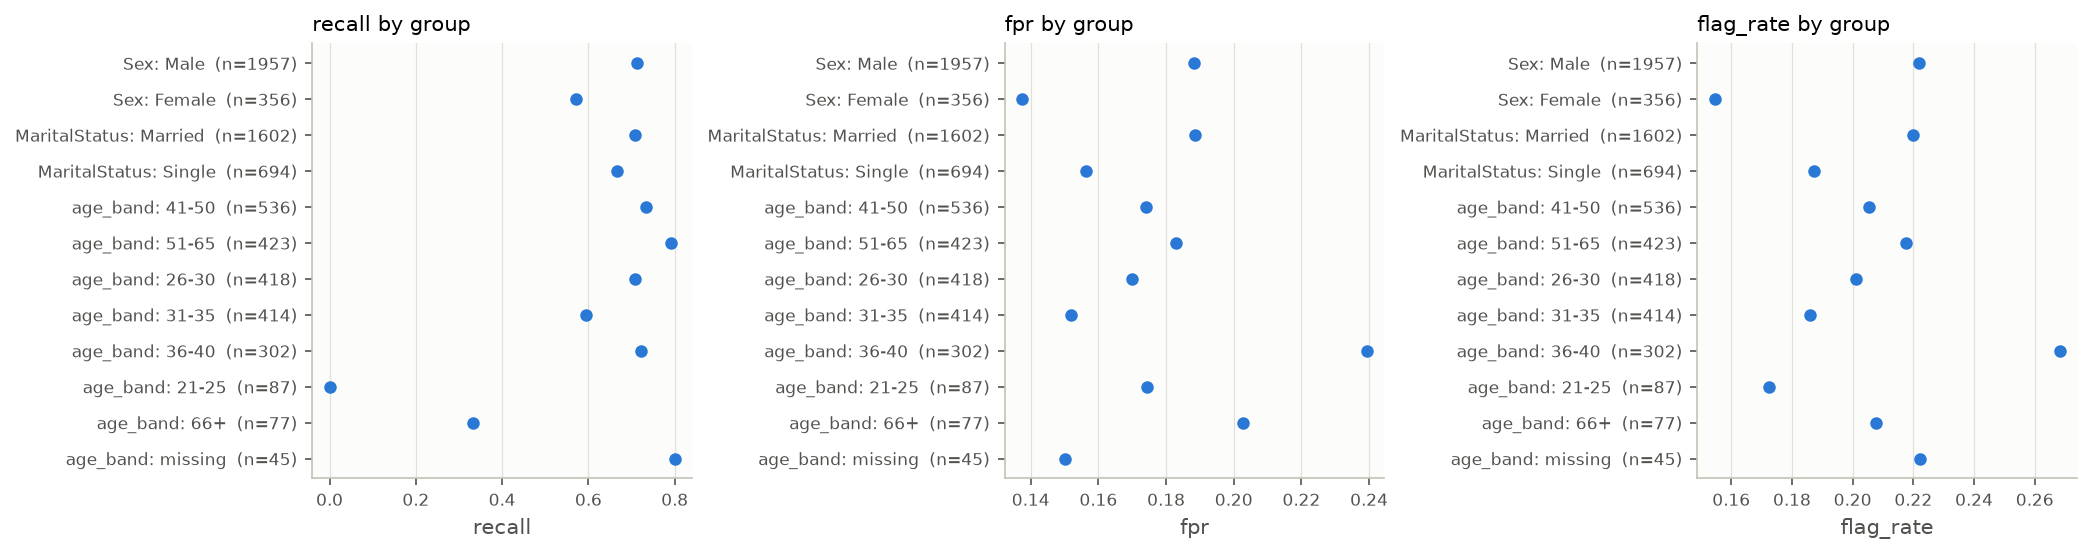

In [14]:
if RUN_SECTIONS["final_evaluation"]:
    err = run.error_analysis()
    print("Segments where frauds are missed most (n >= 50, recall lowest):")
    display(err[(err.n >= 50) & (err.fraud > 0)].sort_values("recall").head(8).round(3))
    print("Segments most over-flagged (highest false-positive rate, n >= 50):")
    display(err[err.n >= 50].sort_values("fpr", ascending=False).head(8).round(3))
    fair = run.fairness()
    display(fair.round(3))
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
    for ax, metric in zip(axes, ["recall", "fpr", "flag_rate"]):
        t = fair[fair.n >= 30]
        eda.plot_dots(ax, (t.attribute + ": " + t.group.astype(str) + "  (n=" + t.n.astype(str) + ")").tolist(),
                      {metric: (t[metric], None, None)}, metric)
        ax.set_title(f"{metric} by group", loc="left", fontsize=10)
    fig.tight_layout(); eda.save(fig, FIG / "fairness.png"); display(Image(FIG / "fairness.png"))

## 10. Save artifacts and package the outputs for download

In [15]:
if RUN_SECTIONS["save"] and RUN_SECTIONS["final_model"]:
    run.save_artifacts()     # re-save with the evaluation, SHAP explainer and final model card
    print(json.dumps({k: run.card[k] for k in ("model_version", "family", "risk_bands", "fast_mode")}, indent=2))
    # Verify the artifacts load and score on CPU, exactly as on the laptop
    from src.ml.predict import load_artifacts, score_claims
    load_artifacts.cache_clear()
    art = load_artifacts(str(OUT / "models"))
    print(score_claims(run.val.head(3), art))
zip_path = run.zip_outputs()
print("DOWNLOAD THIS FILE:", zip_path)

[12:15:08] saved artifacts to /home/user/AgenticAIFraudInsuranceDetection/notebooks/outputs/models: fraud_model.joblib, model_card.json, preprocessor.joblib, shap_explainer.pkl


{
  "model_version": "xgboost-fast-20261005-1215",
  "family": "xgboost",
  "risk_bands": {
    "medium": 0.07207935452461242,
    "high": 0.11788880750536919
  },
  "fast_mode": true
}
[{'fraud_probability': 0.21246500313282013, 'risk_band': 'high', 'thresholds': {'medium': 0.07207935452461242, 'high': 0.11788880750536919}, 'model_version': 'xgboost-fast-20261005-1215'}, {'fraud_probability': 0.002420000033453107, 'risk_band': 'low', 'thresholds': {'medium': 0.07207935452461242, 'high': 0.11788880750536919}, 'model_version': 'xgboost-fast-20261005-1215'}, {'fraud_probability': 0.2356330007314682, 'risk_band': 'high', 'thresholds': {'medium': 0.07207935452461242, 'high': 0.11788880750536919}, 'model_version': 'xgboost-fast-20261005-1215'}]


[12:15:08] wrote /home/user/AgenticAIFraudInsuranceDetection/notebooks/b200_outputs_20261005_121508.zip (7.5 MB)


DOWNLOAD THIS FILE: /home/user/AgenticAIFraudInsuranceDetection/notebooks/b200_outputs_20261005_121508.zip
